### Script to get average beam energy per run for GMn/nTPE confidurations using `HALLA_p` (from E tree) variable [CREATED 02/08/23]
Until now we have been using a beam enrgy number that was put in the GMn run list by the shift crew but that is not precise enough for physics analysis. Hence, I am trying to determine the best was to get the beam energy for all the runs. Observations we make using this script should give us some insight on the above mentioned matter.
#### Issues
1. `HALLA_p` variable that carries the beam energy we get from some EPICS variable can be found in the EPICS tree (E) as well as the T tree. There is a caveat though. EPICS events are only once in 2 seconds or so whereas our event rate is ~ 3.5kHz. As a consequence, we don't have a beam energy value for every physics event. So, it is not a one-to-one mapping between E tree and T tree.
2. Our replay takes care of the above mentioned issue to some extent by recording the same EPICS value for every physics event between two EPICS events. This would mean that we should just be able to use `HALLA_p` variable from T tree two get beam energy every event but there is still another issue. Since, we have recorder huge amount of data every run, our raw data file (.evio) as well as the replay file have several segments per run. Whenever there is a change of segment during replay, podd fills the `HALLA_p` variable with some absurdly large negative number until it fins the first EPICS event. As a result, at the beginning of every segment a bunch of events don't really have a HALLA_p value. Since, we don't really don't store info about the segment number in the tree, surpassing this issue becomes complicated. 

#### Possible Approaches 
1. Defining event range: Andrew's idea, "A better approach is to chain together all the root files from a given run and then define event ranges and beam energy values between EPICS events from the EPICS tree (“E”). For some of the pass 0 and pass 1 replays this method won’t work, since the global event counting is not working properly in earlier versions of SBS-offline/Podd. But that is the scheme you probably want to implement for the final analysis. That method would guarantee that every event after the first EPICS event in any given CODA run will have a valid HALLA_p value (assuming the beam was on when that event was recorded, but that is a separate issue). For the events from the beginning of the run to the first EPICS event you could use the HALLA_p from the first EPICs event."
2. The **easiest approach** is to get an average `HALLA_p` value per run by looping through E tree and use that number for analysis. Here is Andrew's opinion on this, "In the mean time, a safer but arguably less precise approach would be to take the average of all HALLA_p values in the EPICs tree and use that as a single beam energy value for analysis of a given run. Because the EPICs events are “slow” you aren’t really getting an “instantaneous” beam energy that is in sync with the physics events anyway. So just using an average is probably just as good in terms of accuracy." <span style="color:red">We will take this approach in this script.</span>

#### Implementation Ideas
1. For the 2nd approach I want to do the following:
    - Create a CSV file with run number and average HALLA_p values per run for every configuration per target type.
    - Then while looping through the T tree for physics analysis I will grab the run number for every event and read the `HALLA_p` value from the CSV file.
2. For the 1st approach I plan to do the following:
    - Sort by segment numbers before chaining together ROOT files from a given run.
    - For a unique run use the `HALLA_p` branch from tree and then replace the large negative values of the first however many events with the `HALLA_p` value of the last event of previous segment. NOTE: In case of `seg0-0` use a table that contain the first `HALLA_p` value per runnumber.

In [98]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [99]:
# Reading config file
conf_file = open('conf_get_avgHALLA_p_prun_sbs11.json')
conf = json.load(conf_file)
print("Config file for SBS-{}, {} data has been loaded..".format(conf['SBS_config'], conf['target']))

Config file for SBS-11, LH2 data has been loaded..


In [100]:
# Reading CSV file generated from get_avgHALLA_p_prun.cpp script. It should contain HALLA_p values and global event numbers per run
ebeamdf = pd.DataFrame(pd.read_csv("get_HALLA_p_prun_SBS{}_{}.csv".format(conf['SBS_config'], conf['target'])))
ebeamdf['HALLA_p_gev'] = ebeamdf['HALLA_p'] / 1000.0  # let's add a column for ebeam value in GeV
ebeamdf.head()

,runnum,evnum,HALLA_p,HALLA_p_gev
0,12313,293,9859.66,9.85966
1,12313,466,9859.66,9.85966
2,12313,625,9859.66,9.85966
3,12313,795,9859.66,9.85966
4,12313,945,9859.66,9.85966


In [101]:
# Calculating mean and std of beam energy per run
avgebeamdf = ebeamdf.groupby('runnum').agg({'HALLA_p_gev':['mean','std']}).reset_index()
avgebeamdf.head()

runnum HALLA_p_gev          
                mean       std
0  12313    9.859146  0.000266
1  12320    9.859618  0.000378
2  12335    9.269379  2.343329
3  12336    9.859392  0.000336
4  12340    9.859513  0.000124

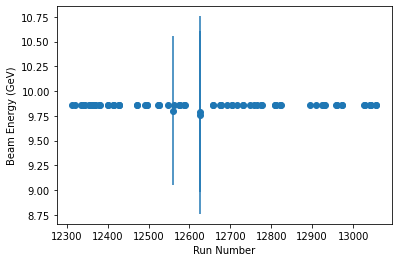

In [102]:
# Plotting average HALLA_p as a function of run numbers (std values are shown as yerrors)
cut_sigma = avgebeamdf['HALLA_p_gev']['std'] < 1 #0.0006 # Defining a cut definition to choose range of std
plt.errorbar(avgebeamdf['runnum'][cut_sigma], avgebeamdf['HALLA_p_gev']['mean'][cut_sigma], yerr=avgebeamdf['HALLA_p_gev']['std'][cut_sigma], fmt='o')
#plt.xticks(avgebeamdf['runnum'], rotation=90)
#plt.xlim(12670,12700)
plt.xlabel('Run Number')
plt.ylabel('Beam Energy (GeV)')
plt.show()

### Filtering out ebeamdf for the following two things
1. HALLA_p > 0
2. Unique EPICS event for a unique global event

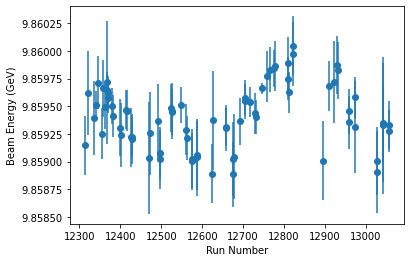

In [103]:
# 1. HALLA_p > 0
ebeamdf_nz = ebeamdf[ebeamdf['HALLA_p'] != 0] # applying the filter
# Calculating mean and std of beam energy per run again with filtered data
avgebeamdf_nz = ebeamdf_nz.groupby('runnum').agg({'HALLA_p_gev':['mean','std']}).reset_index()
# Plotting average HALLA_p as a function of run numbers (std values are shown as yerrors)
cut_sigma_nz = avgebeamdf_nz['HALLA_p_gev']['std'] < 1 #0.0006 # Defining a cut definition to choose range of std
plt.errorbar(avgebeamdf_nz['runnum'][cut_sigma], avgebeamdf_nz['HALLA_p_gev']['mean'][cut_sigma], yerr=avgebeamdf_nz['HALLA_p_gev']['std'][cut_sigma], fmt='o')
#plt.xticks(avgebeamdf['runnum'], rotation=90)
#plt.xlim(12670,12700)
plt.xlabel('Run Number')
plt.ylabel('Beam Energy (GeV)')
plt.show()

In [104]:
# 2. Unique EPICS event for a unique global event
ebeamdf_nz_nd = ebeamdf_nz.drop_duplicates(subset=['runnum', 'evnum'], keep='first')
ebeamdf_nz_nd.head()

,runnum,evnum,HALLA_p,HALLA_p_gev
0,12313,293,9859.66,9.85966
1,12313,466,9859.66,9.85966
2,12313,625,9859.66,9.85966
3,12313,795,9859.66,9.85966
4,12313,945,9859.66,9.85966


In [105]:
# Calculating total no of EPICS events per run before and after filtering duplicate entries
# before
nevents_epics_bf = ebeamdf_nz['runnum'].value_counts().reset_index()
nevents_epics_bf_df = pd.DataFrame(nevents_epics_bf)
nevents_epics_bf_df.columns = ['runnum', 'nevents']
#nevents_epics.to_frame() # this is not working! No clue why!
# after
nevents_epics_af = ebeamdf_nz_nd['runnum'].value_counts().reset_index()
nevents_epics_af_df = pd.DataFrame(nevents_epics_af)
nevents_epics_af_df.columns = ['runnum', 'nevents']
# calculate difference for a particular run
#nevents_epics_bf_df[nevents_epics_bf_df['runnum'] == 12902] - nevents_epics_af_df[nevents_epics_af_df['runnum'] == 12902]

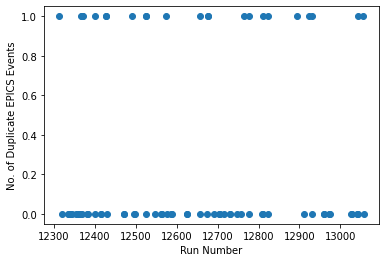

In [106]:
# Take difference in total number of EPICS events before and after and then plot the values vs run numbers
ndup_prun = pd.merge(nevents_epics_bf, nevents_epics_af, on='runnum', suffixes=('', '_ndup'))
ndup_prun['ndup'] = ndup_prun['nevents'] - ndup_prun['nevents_ndup']
plt.scatter(x=ndup_prun['runnum'], y=ndup_prun['ndup'])
plt.xlabel('Run Number')
plt.ylabel('No. of Duplicate EPICS Events')
plt.show()

In [107]:
# # Calculating final mean and std of beam energy per run with completely filtered data
avgebeamdf_nz_nd = ebeamdf_nz_nd.groupby('runnum').agg({'HALLA_p_gev':['mean','std']}).reset_index()
avgebeamdf_nz_nd.head()

runnum HALLA_p_gev          
                mean       std
0  12313    9.859147  0.000266
1  12320    9.859618  0.000378
2  12335    9.859249  0.000286
3  12336    9.859392  0.000336
4  12340    9.859513  0.000124

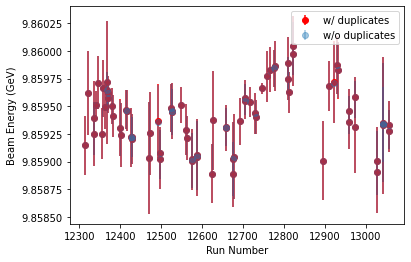

In [108]:
# Plotting HALLA_p as a function of run numbers w/ and w/o cuts on duplicate EPICS events
cut_sigma = avgebeamdf_nz['HALLA_p_gev']['std'] < 1
cut_sigma_nd = avgebeamdf_nz_nd['HALLA_p_gev']['std'] < 1
plt.errorbar(avgebeamdf_nz['runnum'][cut_sigma], avgebeamdf_nz['HALLA_p_gev']['mean'][cut_sigma], yerr=avgebeamdf_nz['HALLA_p_gev']['std'][cut_sigma], fmt='o', color='r', label='w/ duplicates')
plt.errorbar(avgebeamdf_nz_nd['runnum'][cut_sigma], avgebeamdf_nz_nd['HALLA_p_gev']['mean'][cut_sigma_nd], yerr=avgebeamdf_nz_nd['HALLA_p_gev']['std'][cut_sigma_nd], fmt='o', alpha=0.4, label='w/o duplicates')
#plt.xticks(sbs11_ld2_mean_std_p_run_nz_nd['runnum'], rotation=90)
#plt.xlim(12650,12700)
plt.legend()
plt.xlabel('Run Number')
plt.ylabel('Beam Energy (GeV)')
plt.show()

In [109]:
# Getting tables with HALLA_p_mean and HALLA_p_std per run and saving the values in a CSV file
trun_nz_nd = avgebeamdf_nz_nd['runnum']
tmean_nz_nd = avgebeamdf_nz_nd['HALLA_p_gev']['mean']
tstd_nz_nd = avgebeamdf_nz_nd['HALLA_p_gev']['std']
tm1_nz_nd = pd.merge(trun_nz_nd, tmean_nz_nd, left_index=True, right_index=True)
final_table_nz_nd = pd.merge(tm1_nz_nd, tstd_nz_nd, left_index=True, right_index=True)
final_table_nz_nd.columns = ['runnum', 'ebeam_mean', 'ebeam_std']
final_table_nz_nd.head()
# write out a csv file
outfile = '../../DB/avg_ebeam_prun_sbs{}_{}.csv'.format(conf['SBS_config'], conf['target'])
final_table_nz_nd.to_csv(outfile, index=False)
print("Average beam energy per run for SBS-{}, {} data has been written to {}.".format(conf['SBS_config'], conf['target'], outfile))

Average beam energy per run for SBS-11, LH2 data has been written to ../../DB/avg_ebeam_prun_sbs11_LH2.csv.


In [110]:
#final_table_nz_nd['ebeam_std'].max() - final_table_nz['ebeam_std'].max()
#final_table_nz_nd['ebeam_std'][final_table_nz_nd['runnum'] != 12902].max()
final_table_nz_nd['ebeam_mean'].mean()

9.859410624864738